# Import libraries

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from datetime import date

# Get current year

In [153]:
# calculate current year dynamically to be used further on
current_date = date.today()
current_year = current_date.year
print('Current Year: ', current_year)

Current Year:  2026


# Loading data
replacing spaces in cells with nan, naming columns

In [154]:

excel_path = "ToR Structures_Data_Updated- bahman 1405.xlsx"
df_raw= pd.read_excel(
  excel_path, 
  skiprows = 2, 
  header=None,
  sheet_name="Bridge Data"
  )
df_trim = df_raw.replace(r"^\s*$", np.nan, regex=True)

In [155]:
df_trim.columns = [
    "Structure_ID",
    "Bridge_Cat",
    "Hwy_ID",
    "Hwy_Dir",
    "KM",
    "Usage_Code",
    "Replacement_Cost",
    "First_Year_In_Service",
    "Unique_Span_Type",
    "Max_Span_Ln",
    "No_of_Spans",
    "Nominal_Bridge_Ln",
    "Total_Clear_Roadway",
    "Cond_Rat_Deck",
    "Cond_Rat_Super",
    "Cond_Rat_Sub",
    "Insp_Date",
    "Traffic_Volume",
]

In [156]:
display(df_trim.columns.tolist())

['Structure_ID',
 'Bridge_Cat',
 'Hwy_ID',
 'Hwy_Dir',
 'KM',
 'Usage_Code',
 'Replacement_Cost',
 'First_Year_In_Service',
 'Unique_Span_Type',
 'Max_Span_Ln',
 'No_of_Spans',
 'Nominal_Bridge_Ln',
 'Total_Clear_Roadway',
 'Cond_Rat_Deck',
 'Cond_Rat_Super',
 'Cond_Rat_Sub',
 'Insp_Date',
 'Traffic_Volume']

In [157]:
display(df_trim.info())

<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Structure_ID           161 non-null    str    
 1   Bridge_Cat             161 non-null    str    
 2   Hwy_ID                 161 non-null    str    
 3   Hwy_Dir                161 non-null    str    
 4   KM                     161 non-null    float64
 5   Usage_Code             109 non-null    str    
 6   Replacement_Cost       161 non-null    float64
 7   First_Year_In_Service  161 non-null    int64  
 8   Unique_Span_Type       161 non-null    str    
 9   Max_Span_Ln            161 non-null    float64
 10  No_of_Spans            161 non-null    int64  
 11  Nominal_Bridge_Ln      161 non-null    float64
 12  Total_Clear_Roadway    161 non-null    float64
 13  Cond_Rat_Deck          161 non-null    float64
 14  Cond_Rat_Super         161 non-null    float64
 15  Cond_Rat_Sub     

None

In [158]:
display(df_trim.describe().T)

,count,mean,std,min,25%,50%,75%,max
KM,161.0,1.928955e+01,1.441731e+01,0.000000,8.099000,1.603400e+01,2.955500e+01,6.090900e+01
Replacement_Cost,161.0,1.894461e+06,1.501268e+06,44744.264740,914613.985994,1.508536e+06,2.534100e+06,8.418120e+06
First_Year_In_Service,161.0,1.975969e+03,1.617190e+01,1904.000000,1965.000000,1.976000e+03,1.988000e+03,2.012000e+03
Max_Span_Ln,161.0,2.533230e+01,1.412076e+01,1.800000,14.000000,2.440000e+01,3.440000e+01,6.920000e+01
No_of_Spans,161.0,2.881988e+00,1.296046e+00,1.000000,2.000000,3.000000e+00,4.000000e+00,8.000000e+00
Nominal_Bridge_Ln,161.0,1.051723e+02,8.218746e+01,2.634279,48.823638,8.364502e+01,1.359724e+02,4.785250e+02
Total_Clear_Roadway,161.0,1.707172e+01,5.433387e+00,3.256962,13.504347,1.672336e+01,2.056729e+01,4.726920e+01
Cond_Rat_Deck,161.0,5.492538e+01,9.520578e+00,28.045364,49.601372,5.515385e+01,6.128528e+01,8.116442e+01
Cond_Rat_Super,161.0,5.825630e+01,1.067037e+01,17.942491,51.403529,5.825911e+01,6.627448e+01,8.652168e+01
Cond_Rat_Sub,161.0,4.406989e+01,9.947882e+00,17.606721,36.539790,4.408486e+01,5.178123e+01,6.757765e+01


In [159]:
display(df_trim.head(5))

,Structure_ID,Bridge_Cat,Hwy_ID,Hwy_Dir,KM,Usage_Code,Replacement_Cost,First_Year_In_Service,Unique_Span_Type,Max_Span_Ln,No_of_Spans,Nominal_Bridge_Ln,Total_Clear_Roadway,Cond_Rat_Deck,Cond_Rat_Super,Cond_Rat_Sub,Insp_Date,Traffic_Volume
0,B1,STD,135A,C,14.818,RV,2.511241e+05,1975,VS,6.1,1,11.670669,21.488884,64.093956,64.222792,43.155013,2018,15562
1,B2,MAJ,231B,C,23.774,RV,4.463536e+06,1978,VF,36.6,4,251.228128,16.919171,54.069649,71.158214,56.166394,2018,8773
2,B3,MAJ,150A,C,21.298,RV,1.019767e+06,1959,PJ,18.9,3,83.830345,11.835841,60.531122,54.210105,34.689818,2019,2277
3,B4,MAJ,135F,C,41.787,NaN,6.700095e+05,1992,SCC,12.0,3,51.404896,12.470936,54.876023,67.320241,39.173237,2017,7101
4,B5,MAJ,132B,C,11.901,RO,1.282953e+06,1958,CT,23.8,3,58.376076,20.657971,53.329184,64.345511,60.535190,2018,1840


# Calculate current bridge rate conditions (current year 2026).
Calculate years passed from last inspection for each bridge.

In [160]:
df_trim["Insp_Year"] = pd.to_numeric(
    df_trim["Insp_Date"].astype(str).str.split("-").str[-1], errors="coerce"
)

df_trim["Years_Passed"] = current_year - df_trim["Insp_Year"]

In [161]:
cond_cols = ["Cond_Rat_Deck", "Cond_Rat_Super", "Cond_Rat_Sub"]
for col in cond_cols:
    df_trim[col] = pd.to_numeric(df_trim[col], errors="coerce")

In [162]:
df_trim["Unique_Span_Type"] = (
    df_trim["Unique_Span_Type"].astype(str).str.strip()
)

Assign Bridge Types.

In [163]:
bridge_types = {
  "Standard": {
    "Timber": ["TP", "TT"],
    "Prestressed": ["SCC", "SM", "SMC", "VS", "VSO"],
    "Precast": ["HC"],
  },
  "Major": {
    "Concrete": {
      "Pre_stressed_girder": ["CBC", "DBC", "CBT", "DBT", "FC", "FM", "LF", "PJ", "PM", "PO", "PQ", "RD", "RM", "VF"],
      "Pre_cast_girder": ["PE"],
      "Cast_in_place": ["CA", "CF", "CS", "CT", "CV", "CX"],
    },
    "Steel": {
      "Beam": ["FR", "WG", "RB", "RG"],
      "Truss": ["TH"],
    },
  },
}

Define function to calculate bridge condition rate decay based off:
1. initial decay rate
2. bridge type (e.g "STD", "MAJ")
3. unique span type (e.g "FR", "TT")
4. years passed from last inspection

In [164]:
def calculate_decay(initial_rating, bridge_type, unique_span_type, years):
    if pd.isna(initial_rating) or pd.isna(bridge_type) or pd.isna(years):
        return initial_rating
    current_rating = initial_rating
    bridge_type = bridge_type.strip()
    for _ in range(int(years)):
        rate = 0
        if bridge_type == "STD":
            if current_rating >= 88:
                rate = 2.7
            elif current_rating < 88 and current_rating >= 77:
                rate = 1.4
            elif current_rating < 77 and current_rating >= 66:
                rate = 1.7
            elif current_rating < 66 and current_rating >= 55:
                rate = 1.3
            elif current_rating < 55 and current_rating >= 44:
                rate = 1.3
            elif current_rating < 44 and current_rating >= 33:
                rate = 2.1
            elif current_rating < 33 and current_rating >= 22:
                rate = 3.1
            elif current_rating < 22 and current_rating >= 11:
                rate = 2.8
        elif bridge_type == "MAJ":
            if unique_span_type in bridge_types["Major"]["Concrete"]["Pre_stressed_girder"]:
                if current_rating >= 88:
                    rate = 2.2
                elif current_rating < 88 and current_rating >= 77:
                    rate = 1.5
                elif current_rating < 77 and current_rating >= 66:
                    rate = 1.3
                elif current_rating < 66 and current_rating >= 55:
                    rate = 1.1
                elif current_rating < 55 and current_rating >= 44:
                    rate = 1.4
                elif current_rating < 44 and current_rating >= 33:
                    rate = 1.6
                elif current_rating < 33 and current_rating >= 22:
                    rate = 2.1
                elif current_rating < 22 and current_rating >= 11:
                    rate = 3.7
            if unique_span_type in bridge_types["Major"]["Concrete"]["Pre_cast_girder"]:
                if current_rating >= 88:
                    rate = 5.4
                elif current_rating < 88 and current_rating >= 77:
                    rate = 1.8
                elif current_rating < 77 and current_rating >= 66:
                    rate = 1.4
                elif current_rating < 66 and current_rating >= 55:
                    rate = 1.1
                elif current_rating < 55 and current_rating >= 44:
                    rate = 1.1
                elif current_rating < 44 and current_rating >= 33:
                    rate = 1.3
                elif current_rating < 33 and current_rating >= 22:
                    rate = 1.9
                elif current_rating < 22 and current_rating >= 11:
                    rate = 3.7
            if unique_span_type in bridge_types["Major"]["Concrete"]["Cast_in_place"]:
                if current_rating >= 88:
                    rate = 4.2
                elif current_rating < 88 and current_rating >= 77:
                    rate = 2.2
                elif current_rating < 77 and current_rating >= 66:
                    rate = 1.2
                elif current_rating < 66 and current_rating >= 55:
                    rate = 1.3
                elif current_rating < 55 and current_rating >= 44:
                    rate = 1.3
                elif current_rating < 44 and current_rating >= 33:
                    rate = 1.2
                elif current_rating < 33 and current_rating >= 22:
                    rate = 1.8
                elif current_rating < 22 and current_rating >= 11:
                    rate = 4.7
            if unique_span_type in bridge_types["Major"]["Steel"]["Beam"]:
                if current_rating >= 88:
                    rate = 2.6
                elif current_rating < 88 and current_rating >= 77:
                    rate = 1.9
                elif current_rating < 77 and current_rating >= 66:
                    rate = 1.1
                elif current_rating < 66 and current_rating >= 55:
                    rate = 1.4
                elif current_rating < 55 and current_rating >= 44:
                    rate = 1.1
                elif current_rating < 44 and current_rating >= 33:
                    rate = 1.7
                elif current_rating < 33 and current_rating >= 22:
                    rate = 2.1
                elif current_rating < 22 and current_rating >= 11:
                    rate = 2.4
            if unique_span_type in bridge_types["Major"]["Steel"]["Truss"]:
                if current_rating >= 88:
                    rate = 3.6
                elif current_rating < 88 and current_rating >= 77:
                    rate = 3.2
                elif current_rating < 77 and current_rating >= 66:
                    rate = 1.2
                elif current_rating < 66 and current_rating >= 55:
                    rate = 1.4
                elif current_rating < 55 and current_rating >= 44:
                    rate = 1.5
                elif current_rating < 44 and current_rating >= 33:
                    rate = 1.8
                elif current_rating < 33 and current_rating >= 22:
                    rate = 2.7
                elif current_rating < 22 and current_rating >= 11:
                    rate = 7.8

        current_rating -= rate
        if current_rating < 0:
            current_rating = 0
            break

    return round(current_rating, 2)


Calculate Current Bridge Deck, Sub, Super structure Condition rates.

In [165]:
df_trim['current_Cond_Rat_Deck'] = df_trim.apply(
    lambda row: calculate_decay(
        int(row['Cond_Rat_Deck']),
        row['Bridge_Cat'],
        row['Unique_Span_Type'],
        int(row['Years_Passed'])
    ), axis=1
)

df_trim['current_Cond_Rat_Super'] = df_trim.apply(
    lambda row: calculate_decay(
        int(row['Cond_Rat_Super']),
        row['Bridge_Cat'],
        row['Unique_Span_Type'],
        int(row['Years_Passed'])
    ), axis=1
)

df_trim['current_Cond_Rat_Sub'] = df_trim.apply(
    lambda row: calculate_decay(
        int(row['Cond_Rat_Sub']),
        row['Bridge_Cat'],
        row['Unique_Span_Type'],
        int(row['Years_Passed'])
    ), axis=1
)


Display current condition rate calculation output.

In [166]:
display(df_trim.head(3))

,Structure_ID,Bridge_Cat,Hwy_ID,Hwy_Dir,KM,Usage_Code,Replacement_Cost,First_Year_In_Service,Unique_Span_Type,Max_Span_Ln,...,Cond_Rat_Deck,Cond_Rat_Super,Cond_Rat_Sub,Insp_Date,Traffic_Volume,Insp_Year,Years_Passed,current_Cond_Rat_Deck,current_Cond_Rat_Super,current_Cond_Rat_Sub
0,B1,STD,135A,C,14.818,RV,2.511241e+05,1975,VS,6.1,...,64.093956,64.222792,43.155013,2018,15562,2018,8,53.6,53.6,23.2
1,B2,MAJ,231B,C,23.774,RV,4.463536e+06,1978,VF,36.6,...,54.069649,71.158214,56.166394,2018,8773,2018,8,42.8,61.4,45.1
2,B3,MAJ,150A,C,21.298,RV,1.019767e+06,1959,PJ,18.9,...,60.531122,54.210105,34.689818,2019,2277,2019,7,51.7,44.2,18.2


# Calculate BCI
calculate bridge condition index based on:
1. current bridge super, sub, deck condition rates.
2. constant super(0.35), sub(0.35), deck(0.4) weights.

In [167]:
bridge_deck_weight = 0.3
bridge_super_structure_weight = 0.35
bridge_sub_structure_weight = 0.35

df_trim["BCI"] = (bridge_deck_weight * df_trim["current_Cond_Rat_Deck"] + 
  bridge_super_structure_weight * df_trim["current_Cond_Rat_Super"] + 
  bridge_sub_structure_weight * df_trim["current_Cond_Rat_Sub"]
  )
display(df_trim.head(3))

,Structure_ID,Bridge_Cat,Hwy_ID,Hwy_Dir,KM,Usage_Code,Replacement_Cost,First_Year_In_Service,Unique_Span_Type,Max_Span_Ln,...,Cond_Rat_Super,Cond_Rat_Sub,Insp_Date,Traffic_Volume,Insp_Year,Years_Passed,current_Cond_Rat_Deck,current_Cond_Rat_Super,current_Cond_Rat_Sub,BCI
0,B1,STD,135A,C,14.818,RV,2.511241e+05,1975,VS,6.1,...,64.222792,43.155013,2018,15562,2018,8,53.6,53.6,23.2,42.960
1,B2,MAJ,231B,C,23.774,RV,4.463536e+06,1978,VF,36.6,...,71.158214,56.166394,2018,8773,2018,8,42.8,61.4,45.1,50.115
2,B3,MAJ,150A,C,21.298,RV,1.019767e+06,1959,PJ,18.9,...,54.210105,34.689818,2019,2277,2019,7,51.7,44.2,18.2,37.350


# Explore data analysis (EDA)

In [168]:
summary = pd.DataFrame({
    "Type": df_trim.dtypes,
    "Missing": df_trim.isna().sum(),
    "Missing %": (df_trim.isna().sum()/len(df_trim)*100).round(2),
    "Unique": df_trim.nunique()
})

display(summary)

,Type,Missing,Missing %,Unique
Structure_ID,str,0,0.0,161
Bridge_Cat,str,0,0.0,2
Hwy_ID,str,0,0.0,60
Hwy_Dir,str,0,0.0,3
KM,float64,0,0.0,159
Usage_Code,str,52,32.3,8
Replacement_Cost,float64,0,0.0,161
First_Year_In_Service,int64,0,0.0,56
Unique_Span_Type,str,0,0.0,35
Max_Span_Ln,float64,0,0.0,80


In [169]:
df_trim.describe().T

,count,mean,std,min,25%,50%,75%,max
KM,161.0,1.928955e+01,1.441731e+01,0.000000,8.099000,1.603400e+01,2.955500e+01,6.090900e+01
Replacement_Cost,161.0,1.894461e+06,1.501268e+06,44744.264740,914613.985994,1.508536e+06,2.534100e+06,8.418120e+06
First_Year_In_Service,161.0,1.975969e+03,1.617190e+01,1904.000000,1965.000000,1.976000e+03,1.988000e+03,2.012000e+03
Max_Span_Ln,161.0,2.533230e+01,1.412076e+01,1.800000,14.000000,2.440000e+01,3.440000e+01,6.920000e+01
No_of_Spans,161.0,2.881988e+00,1.296046e+00,1.000000,2.000000,3.000000e+00,4.000000e+00,8.000000e+00
Nominal_Bridge_Ln,161.0,1.051723e+02,8.218746e+01,2.634279,48.823638,8.364502e+01,1.359724e+02,4.785250e+02
Total_Clear_Roadway,161.0,1.707172e+01,5.433387e+00,3.256962,13.504347,1.672336e+01,2.056729e+01,4.726920e+01
Cond_Rat_Deck,161.0,5.492538e+01,9.520578e+00,28.045364,49.601372,5.515385e+01,6.128528e+01,8.116442e+01
Cond_Rat_Super,161.0,5.825630e+01,1.067037e+01,17.942491,51.403529,5.825911e+01,6.627448e+01,8.652168e+01
Cond_Rat_Sub,161.0,4.406989e+01,9.947882e+00,17.606721,36.539790,4.408486e+01,5.178123e+01,6.757765e+01


calculate age property of each bridge to be used for age distribution histogram.

In [170]:
df_trim["Age"] = current_year - df_trim["First_Year_In_Service"]

df_trim["Condition"] = (
    df_trim["Cond_Rat_Deck"] +
    df_trim["Cond_Rat_Super"] +
    df_trim["Cond_Rat_Sub"]
) / 3

In [171]:
print(f"Number of Bridges: {len(df_trim)}")

print(f"Average Age: {df_trim['Age'].mean():.1f}")

print(f"Average Condition: {df_trim['Condition'].mean():.1f}")

print(f"Minimum Condition: {df_trim['Condition'].min():.1f}")

print(f"Maximum Condition: {df_trim['Condition'].max():.1f}")

Number of Bridges: 161
Average Age: 50.0
Average Condition: 52.4
Minimum Condition: 37.4
Maximum Condition: 64.6


plot bridge category piechart

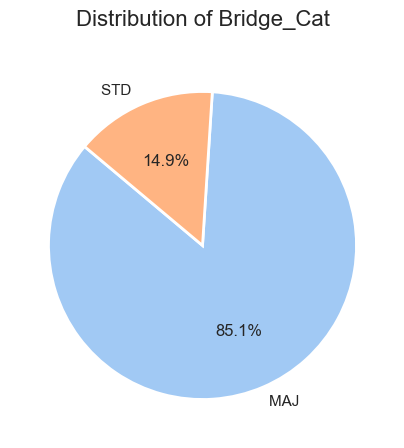

In [183]:
data_counts = df_trim["Bridge_Cat"].value_counts()


sns.set_theme(style="whitegrid")
colors = sns.color_palette('pastel')[0:len(data_counts)] 


plt.figure(figsize=(5, 5))
plt.pie(
    data_counts, 
    labels=data_counts.index, 
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# ۵. افزودن عنوان
plt.title(f'Distribution of {"Bridge_Cat"}', fontsize=16, pad=20)

# نمایش نمودار
plt.show()

Bridge age distribution

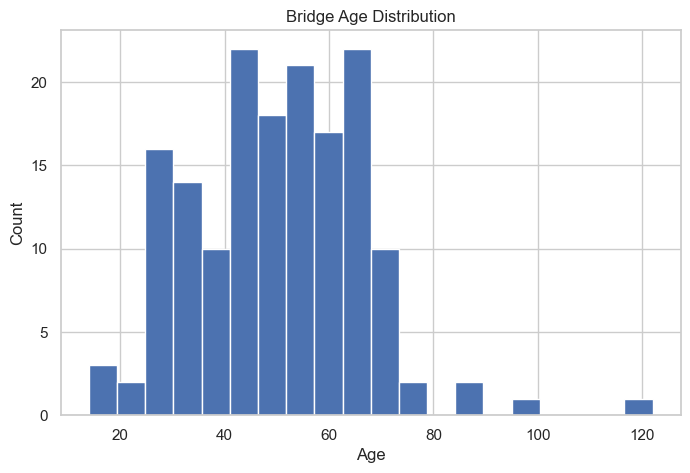

In [173]:
plt.figure(figsize=(8,5))
df_trim["Age"].hist(bins=20)
plt.title("Bridge Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

generate histogram for bridges deck, super, sub conditions

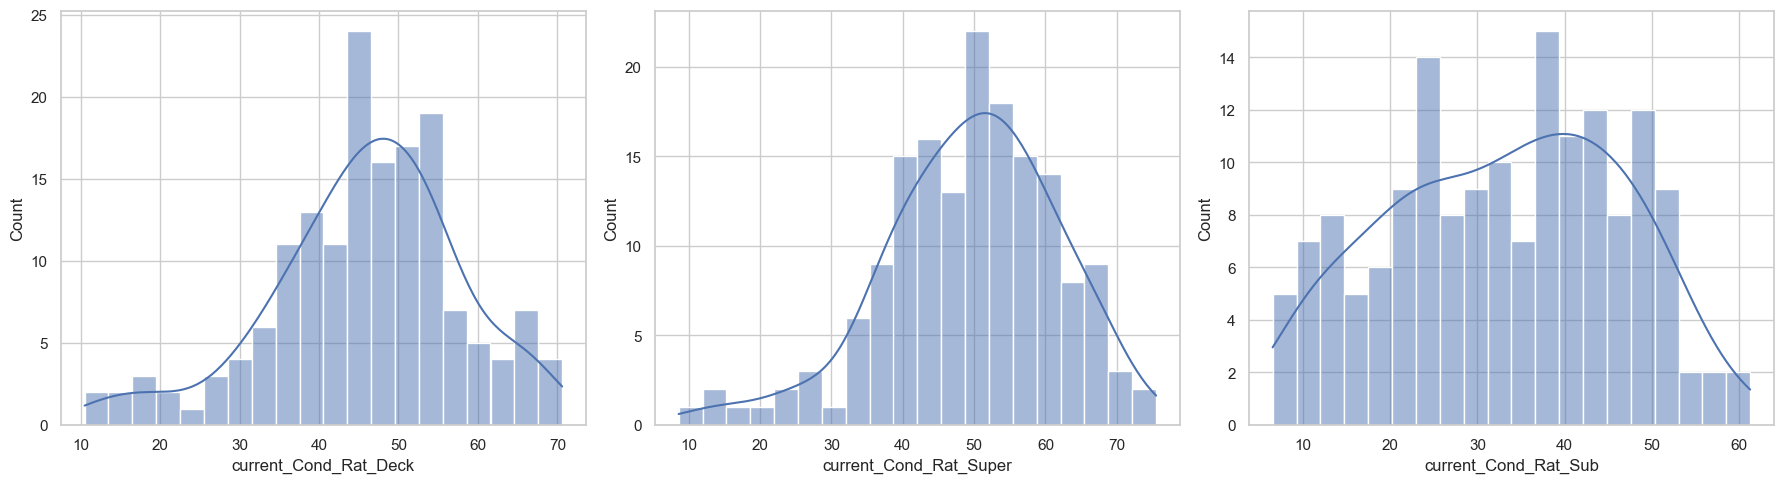

In [174]:
metrics = [
    'current_Cond_Rat_Deck',
    'current_Cond_Rat_Super',
    'current_Cond_Rat_Sub',
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.histplot(
        data=df_trim,
        x=metric,
        bins=20,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


Bridge BCI histogram

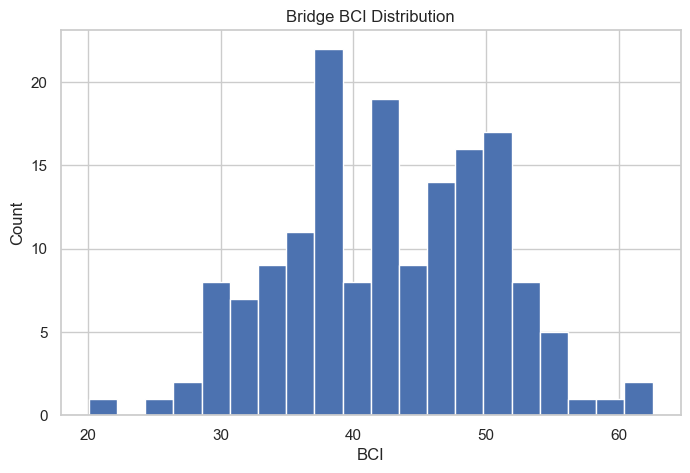

In [175]:
plt.figure(figsize=(8,5))
df_trim["BCI"].hist(bins=20)
plt.title("Bridge BCI Distribution")
plt.xlabel("BCI")
plt.ylabel("Count")
plt.show()

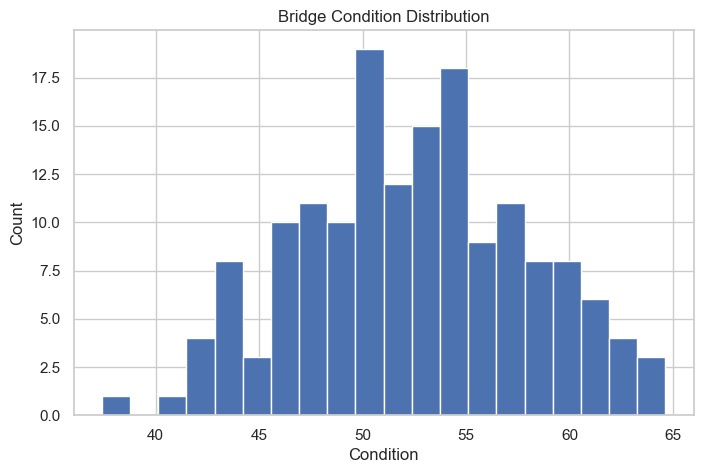

In [176]:
plt.figure(figsize=(8,5))
df_trim["Condition"].hist(bins=20)
plt.title("Bridge Condition Distribution")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

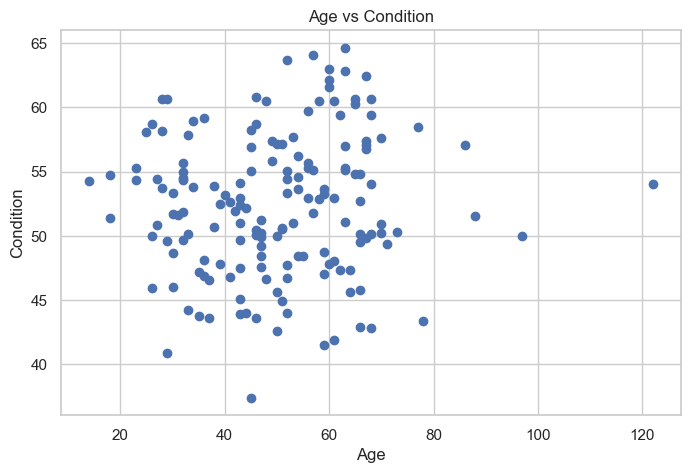

In [178]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_trim["Age"],
    df_trim["Condition"]
)

plt.xlabel("Age")
plt.ylabel("Condition")

plt.title(
    "Age vs Condition"
)

plt.show()

In [179]:
def normalize(series):
    return (
        (series - series.min()) /
        (series.max() - series.min())
    ) * 100

In [180]:
df_trim["Condition_Score"] = normalize(
    100 - df_trim["Condition"]
)

df_trim["Age_Score"] = normalize(
    df_trim["Age"]
)

df_trim["Traffic_Score"] = normalize(
    df_trim["Traffic_Volume"]
)

df_trim["Cost_Score"] = normalize(
    df_trim["Replacement_Cost"]
)

In [181]:
df_trim["Priority Score"] = (
      0.40 * df_trim["Condition_Score"]
    + 0.30 * df_trim["Traffic_Score"]
    + 0.20 * df_trim["Age_Score"]
    + 0.10 * df_trim["Cost_Score"]
)

In [182]:
top10 = (
    df_trim.sort_values(
        "Priority Score",
        ascending=False
    )
    .head(10)
)

display(
    top10[
        [
            "Structure_ID",
            "Priority Score",
            "Condition",
            "Age",
            "Traffic_Volume"
        ]
    ]
)

,Structure_ID,Priority Score,Condition,Age,Traffic_Volume
6,B7,66.624352,47.328337,64,19965
113,B114,66.322165,47.340908,62,19596
72,B73,63.092489,46.717370,52,16226
33,B34,62.865883,43.769734,35,17795
80,B81,62.513822,45.071531,43,17235
41,B42,62.404419,49.540671,66,19556
29,B30,61.923983,50.196179,70,19134
123,B124,61.295509,47.712156,52,18821
120,B121,61.071966,45.649436,50,15440
76,B77,60.284760,37.405210,45,9422
